In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import scipy

In [2]:
data = list(map(float, open("data.txt").read().split(", ")))
n = len(data)

In [3]:
frequency = dict(sorted({x: data.count(x) for x in data}.items(), key=lambda x: x[0]))
frequency

{2.1: 4,
 2.2: 2,
 2.3: 1,
 2.4: 2,
 2.5: 2,
 2.6: 1,
 2.7: 1,
 2.8: 1,
 3.2: 1,
 3.3: 3,
 3.4: 2,
 3.7: 2,
 3.8: 1,
 4.0: 3,
 4.1: 1,
 4.2: 1,
 4.5: 1,
 4.6: 1,
 4.7: 3,
 4.8: 2,
 4.9: 1}

In [4]:
cumulative_frequency = list(frequency.values())
for i in range(1, len(cumulative_frequency)):
	cumulative_frequency[i] = cumulative_frequency[i - 1] + cumulative_frequency[i]

cumulative_frequency

[4,
 6,
 7,
 9,
 11,
 12,
 13,
 14,
 15,
 18,
 20,
 22,
 23,
 26,
 27,
 28,
 29,
 30,
 33,
 35,
 36]

In [5]:
df = pd.DataFrame(
	{
		"x": frequency.keys(),
		"Frequency": frequency.values(),
		"Cumulative Frequency": cumulative_frequency,
		"Probability": [x / len(data) for x in cumulative_frequency]
	}
)
df

,x,Frequency,Cumulative Frequency,Probability
0,2.1,4,4,0.111111
1,2.2,2,6,0.166667
2,2.3,1,7,0.194444
3,2.4,2,9,0.250000
4,2.5,2,11,0.305556
5,2.6,1,12,0.333333
6,2.7,1,13,0.361111
7,2.8,1,14,0.388889
8,3.2,1,15,0.416667
9,3.3,3,18,0.500000


# 1. Построить эмпирическую функцию распределения

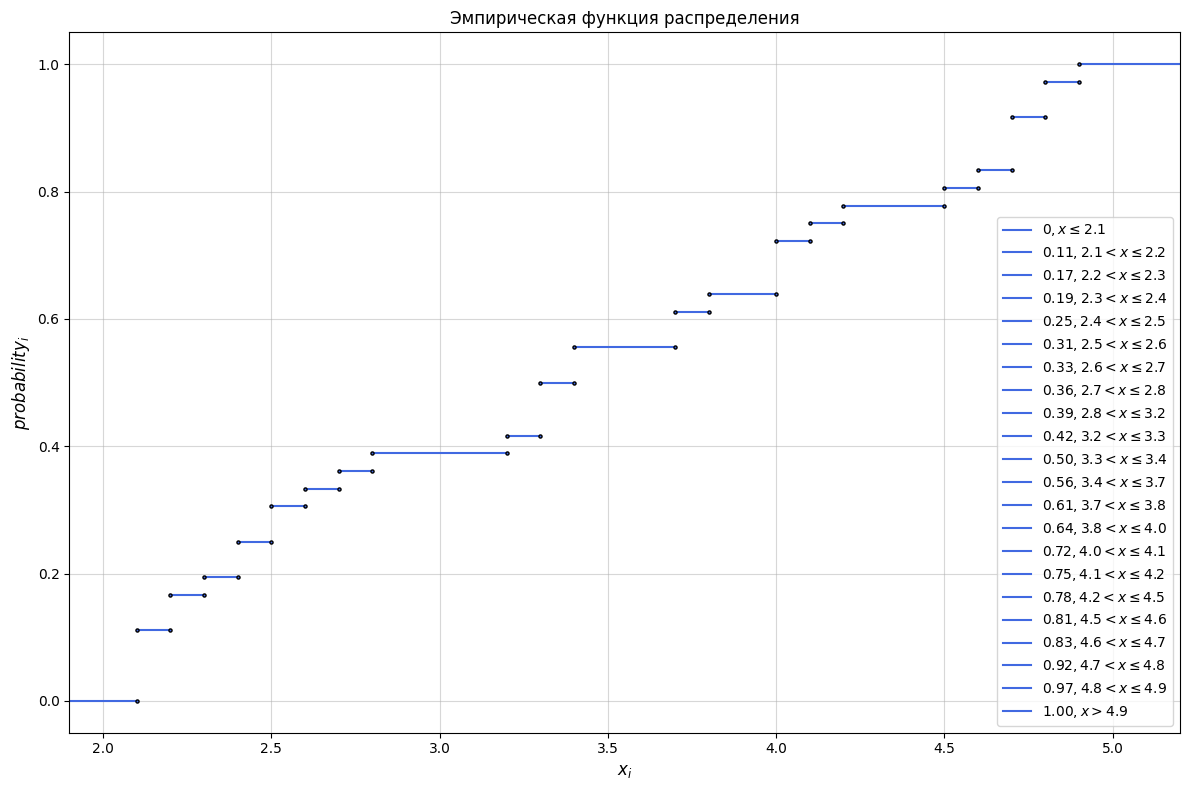

In [6]:
plt.figure(figsize=(12, 8))
plt.xlim(1.9, 5.2)

plt.title("Эмпирическая функция распределения")
plt.xlabel(r"$x_i$", fontsize=12)
plt.ylabel(r"$probability_i$", fontsize=12)

df_iloc_x = df["x"].iloc
df_iloc_probability = df["Probability"].iloc

plt.scatter([0, df_iloc_x[0]], [0, 0], c="royalblue", ec="k", s=5, zorder=3)
plt.plot([0, df_iloc_x[0]], [0, 0], c="royalblue", label=fr"$0, x \leq {df_iloc_x[0]}$")

for i in range(len(df) - 1):
	plt.scatter([df_iloc_x[i], df_iloc_x[i + 1]], [df_iloc_probability[i], df_iloc_probability[i]], c="royalblue", ec="k", s=5, zorder=3)
	plt.plot([df_iloc_x[i], df_iloc_x[i + 1]], [df_iloc_probability[i], df_iloc_probability[i]], c="royalblue", label=fr"${df_iloc_probability[i]:.2f}, {df_iloc_x[i]} < x \leq {df_iloc_x[i + 1]}$")

plt.scatter([df_iloc_x[-1], 6], [df_iloc_probability[-1], df_iloc_probability[-1]], c="royalblue", ec="k", s=5, zorder=3)
plt.plot([df_iloc_x[-1], 6], [df_iloc_probability[-1], df_iloc_probability[-1]], c="royalblue", label=fr"${df_iloc_probability[-1]:.2f}, x > {df_iloc_x[-1]}$")

plt.legend()
plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

# 2. Построить гистограмму и полигон частот.

## 2.1 Гистограмма

Число интервалов по правилу Стёрджеса: k = 7


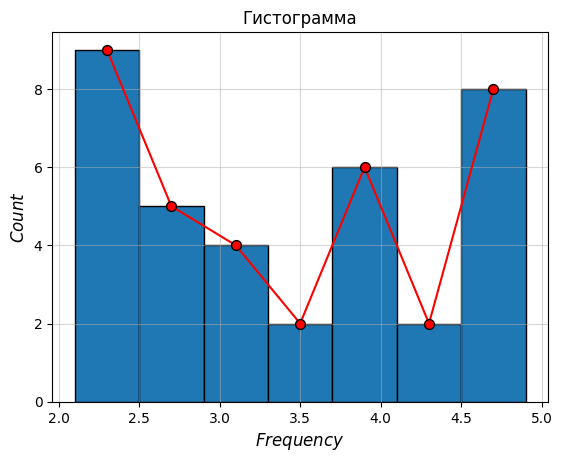

In [7]:
# plt.figure(figsize=(12, 8))

k = int(math.ceil(math.log2(n) + 1))
print(f"Число интервалов по правилу Стёрджеса: {k = }")

plt.title("Гистограмма")
plt.xlabel(r"$Frequency$", fontsize=12)
plt.ylabel(r"$Count$", fontsize=12)

counts, bins, _ = plt.hist(data, bins=k, ec="k")
plt.scatter((bins[1:] + bins[:-1]) / 2, counts, s=50, ec="k", c="red", zorder=3)
plt.plot((bins[1:] + bins[:-1]) / 2, counts, c="red")


plt.grid(alpha=.5)
# plt.tight_layout()
plt.show()

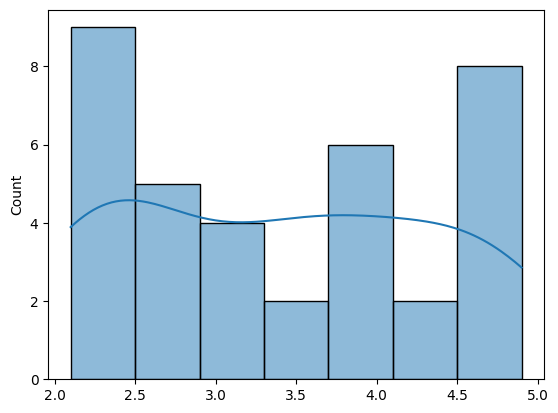

In [8]:
sns.histplot(data, kde=True)
plt.show()

## 2.2 Полигон частот

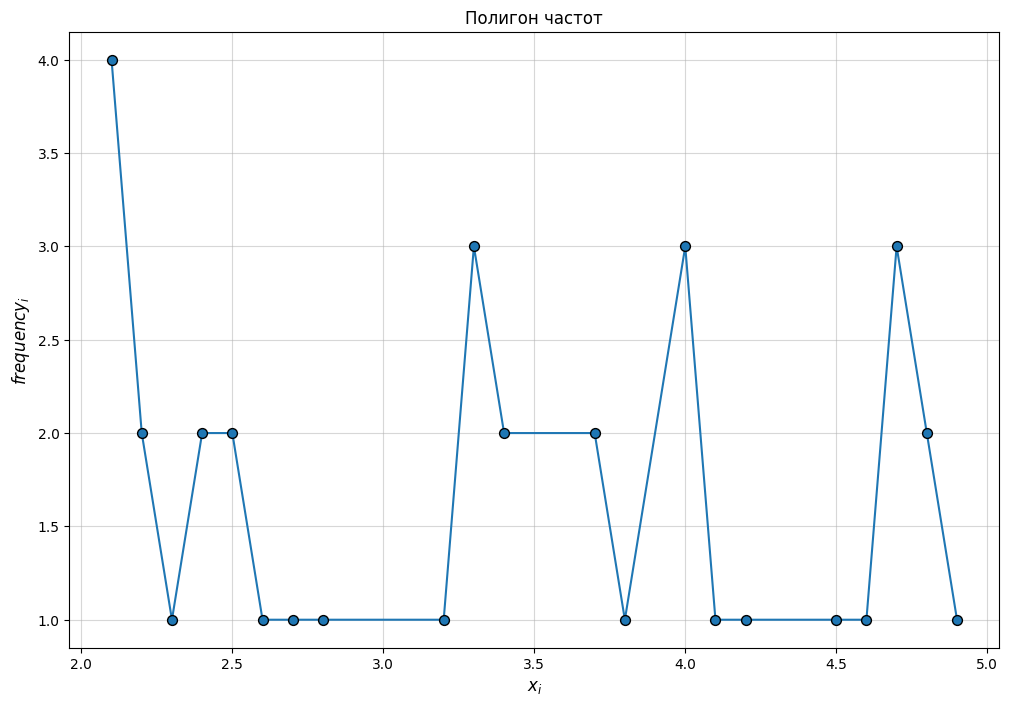

In [9]:
plt.figure(figsize=(12, 8))

plt.title("Полигон частот")
plt.xlabel(r"$x_i$", fontsize=12)
plt.ylabel(r"$frequency_i$", fontsize=12)

plt.scatter(df["x"], df["Frequency"], ec="k", s=50, zorder=3)
plt.plot(df["x"], df["Frequency"])

plt.grid(alpha=.5)
# plt.tight_layout()
plt.show()

# 3 Выполнить проверку на нормальность - Критерий Пирсона, Критерий Романовского, Критерий Шапиро-Уилка.

## 3.1 Критерий Пирсона

In [10]:
middle = sum(data) / n
sigma = (sum([(x - middle) ** 2 for x in data]) / n) ** .5

data_pearson = {
	"Range": [],
	"n": [],
	"p": [],
	"np": [],
	"Result": []
}

# range_ = []
# n = []
# p = []
# np = []
# result = []
for i in range(k):
	if i == (k - 1):
		data_pearson["Range"] += [f"[{bins[-2]:.2f}, {bins[-1]:.2f}]"]
		data_pearson["n"] += [df["Frequency"][(bins[-2] <= df["x"]) & (df["x"] <= bins[-1])].sum()]
	
	else:
		data_pearson["Range"] += [f"[{bins[i]:.2f}, {bins[i + 1]:.2f})"]
		data_pearson["n"] += [df["Frequency"][(bins[i] <= df["x"]) & (df["x"] < bins[i + 1])].sum()]

	data_pearson["p"] += [scipy.stats.norm.cdf((bins[i + 1] - middle) / sigma) - scipy.stats.norm.cdf((bins[i] - middle) / sigma)]
	data_pearson["np"] += [len(data) * data_pearson["p"][i]]
	data_pearson["Result"] += [((data_pearson["n"][i] - data_pearson["np"][i]) ** 2) / data_pearson["np"][i]]

	# if i == (k - 1):
	# 	range_ += [f"[{bins[-2]:.2f}, {bins[-1]:.2f}]"]
	# 	n += [df["Frequency"][(bins[-2] <= df["x"]) & (df["x"] <= bins[-1])].sum()]
	# else:
	# 	range_ += [f"[{bins[i]:.2f}, {bins[i + 1]:.2f})"]
	# 	n += [df["Frequency"][(bins[i] <= df["x"]) & (df["x"] < bins[i + 1])].sum()]

	# p += [scipy.stats.norm.cdf((bins[i + 1] - middle) / sigma) - scipy.stats.norm.cdf((bins[i] - middle) / sigma)]
	# np += [len(data) * p[i]]
	# result += [((n[i] - np[i]) ** 2) / np[i]]


# Pearson = pd.DataFrame(
# 	{
# 		"Range": range_,
# 		"n": n,
# 		"p": p,
# 		"np": np,
# 		"Result": result
# 	}
# )

Pearson = pd.DataFrame(data_pearson)

chi2 = Pearson["Result"].sum()
if chi2 >= scipy.stats.chi2.cdf(1 - .05, df=k - 3):
	print("Отвергаем гипотезу")

else:
	print("Не отвергаем гипотезу")

Отвергаем гипотезу


# 3.2 Критерий Романовского

In [11]:
if abs(chi2 - (k - 3)) / (2 * (k - 3) ** .5) > 3:
	print("Отвергаем гипотезу")

else:
	print("Не отвергаем гипотезу")

Отвергаем гипотезу


# 3.3 Критерий Шапиро-Уилка

$W = \frac{ \left( \sum_{i=1}^{n} a_i \cdot x_{(i)} \right)^2 }{ \sum_{i=1}^{n} (x_i - \bar{x})^2 } \\$
$\\ a_i \approx \frac{m_i^*}{\sqrt{\sum_{j=1}^n (m_j^*)^2}} \\$
где $m_i^*$ — нормальные scores с поправкой на симметрию, часто вычисляемые как:
$\\ m_i^* = \Phi^{-1}\left( \frac{i - 0.375}{n + 0.25} \right)$
где $\Phi^{-1}$ — обратная функция стандартного нормального распределения.

In [12]:
data = sorted(data)

ShapiroWilka = pd.DataFrame(
	{
		"x": data,
		"x_rev": data[::-1]
	}
)

ShapiroWilka["diff"] = abs(ShapiroWilka["x_rev"] - ShapiroWilka["x"])
ShapiroWilka

,x,x_rev,diff
0,2.1,4.9,2.8
1,2.1,4.8,2.7
2,2.1,4.8,2.7
3,2.1,4.7,2.6
4,2.2,4.7,2.5
5,2.2,4.7,2.5
6,2.3,4.6,2.3
7,2.4,4.5,2.1
8,2.4,4.2,1.8
9,2.5,4.1,1.6


In [13]:
W = pd.DataFrame(
	{
		"i": range(1, 37),
		"m_i": [scipy.stats.norm.ppf((i + 1 - .375) / (n + .25)) for i in range(n)]
	}
)

W["m_i^2"] = W["m_i"] ** 2
W["a_i"] = W["m_i"] / (W["m_i^2"].sum() ** .5)

W

,i,m_i,m_i^2,a_i
0,1,-2.114381,4.470606,-0.366089
1,2,-1.697219,2.880554,-0.293861
2,3,-1.458047,2.125901,-0.252450
3,4,-1.281552,1.642374,-0.221891
4,5,-1.137876,1.294761,-0.197015
5,6,-1.014499,1.029208,-0.175653
6,7,-0.904902,0.818848,-0.156677
7,8,-0.805225,0.648388,-0.139419
8,9,-0.712974,0.508331,-0.123446
9,10,-0.626428,0.392412,-0.108461


In [14]:
ShapiroWilka["prod"] = W["a_i"] * ShapiroWilka["diff"]
ShapiroWilka

,x,x_rev,diff,prod
0,2.1,4.9,2.8,-1.025049
1,2.1,4.8,2.7,-0.793424
2,2.1,4.8,2.7,-0.681614
3,2.1,4.7,2.6,-0.576916
4,2.2,4.7,2.5,-0.492536
5,2.2,4.7,2.5,-0.439132
6,2.3,4.6,2.3,-0.360357
7,2.4,4.5,2.1,-0.292779
8,2.4,4.2,1.8,-0.222203
9,2.5,4.1,1.6,-0.173538


In [15]:
if ((ShapiroWilka["prod"].sum() ** 2) / ((ShapiroWilka["x"] - ShapiroWilka["x"].mean()) ** 2).sum()) < .939:
	print("Отвергаем гипотезу")

else:
	print("Не отвергаем гипотезу")

Отвергаем гипотезу
